# Problema 1 - Redes Neuronales para Descarga de Batería (20 Puntos)

Desarrollar un conjunto de redes neuronales para cada voltaje de descarga en función del período de descarga. Graficar todas las redes juntas.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1773432248.466392    9823 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432248.466934    9823 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773432248.607093    9823 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773432250.826475    9823 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432250.826856    9823 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
tiempo = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20], dtype=np.float32)

voltaje_25C = np.array([4.20, 4.05, 3.95, 3.88, 3.82, 3.77, 3.72, 3.68, 3.63, 3.57, 3.40], dtype=np.float32)
voltaje_10C = np.array([3.75, 3.70, 3.68, 3.65, 3.62, 3.58, 3.54, 3.50, 3.45, 3.38, 3.25], dtype=np.float32)
voltaje_0C = np.array([3.50, 3.55, 3.58, 3.59, 3.58, 3.55, 3.50, 3.45, 3.38, 3.30, 3.15], dtype=np.float32)
voltaje_m10C = np.array([3.20, 3.30, 3.38, 3.42, 3.40, 3.35, 3.30, 3.25, 3.20, 3.12, 3.00], dtype=np.float32)

datasets = [
    {'voltaje': voltaje_25C, 'color': 'red', 'label': '25°C'},
    {'voltaje': voltaje_10C, 'color': 'blue', 'label': '10°C'},
    {'voltaje': voltaje_0C, 'color': 'orange', 'label': '0°C'},
    {'voltaje': voltaje_m10C, 'color': 'green', 'label': '-10°C'},
]

In [3]:
tiempo_norm = tiempo / 20.0

def normalizar(v):
    return (v - np.mean(v)) / np.std(v), np.mean(v), np.std(v)

def desnormalizar(v_norm, media, std):
    return v_norm * std + media

In [4]:
def crear_red():
    modelo = keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(10, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(10, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(1, activation='linear')
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
    return modelo

In [5]:
modelos = []
historiales = []
stats = []

for ds in datasets:
    v_norm, v_mean, v_std = normalizar(ds['voltaje'])
    stats.append((v_mean, v_std))
    
    X = tiempo_norm.reshape(-1, 1)
    y = v_norm.reshape(-1, 1)
    
    modelo = crear_red()
    history = modelo.fit(X, y, epochs=2000, batch_size=11, verbose=0,
                         validation_split=0.2,
                         callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)])
    modelos.append(modelo)
    historiales.append(history)
    print(f"Entrenamiento completado para {ds['label']}")

E0000 00:00:1773432251.901936    9823 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Entrenamiento completado para 25°C


Entrenamiento completado para 10°C


Entrenamiento completado para 0°C


Entrenamiento completado para -10°C


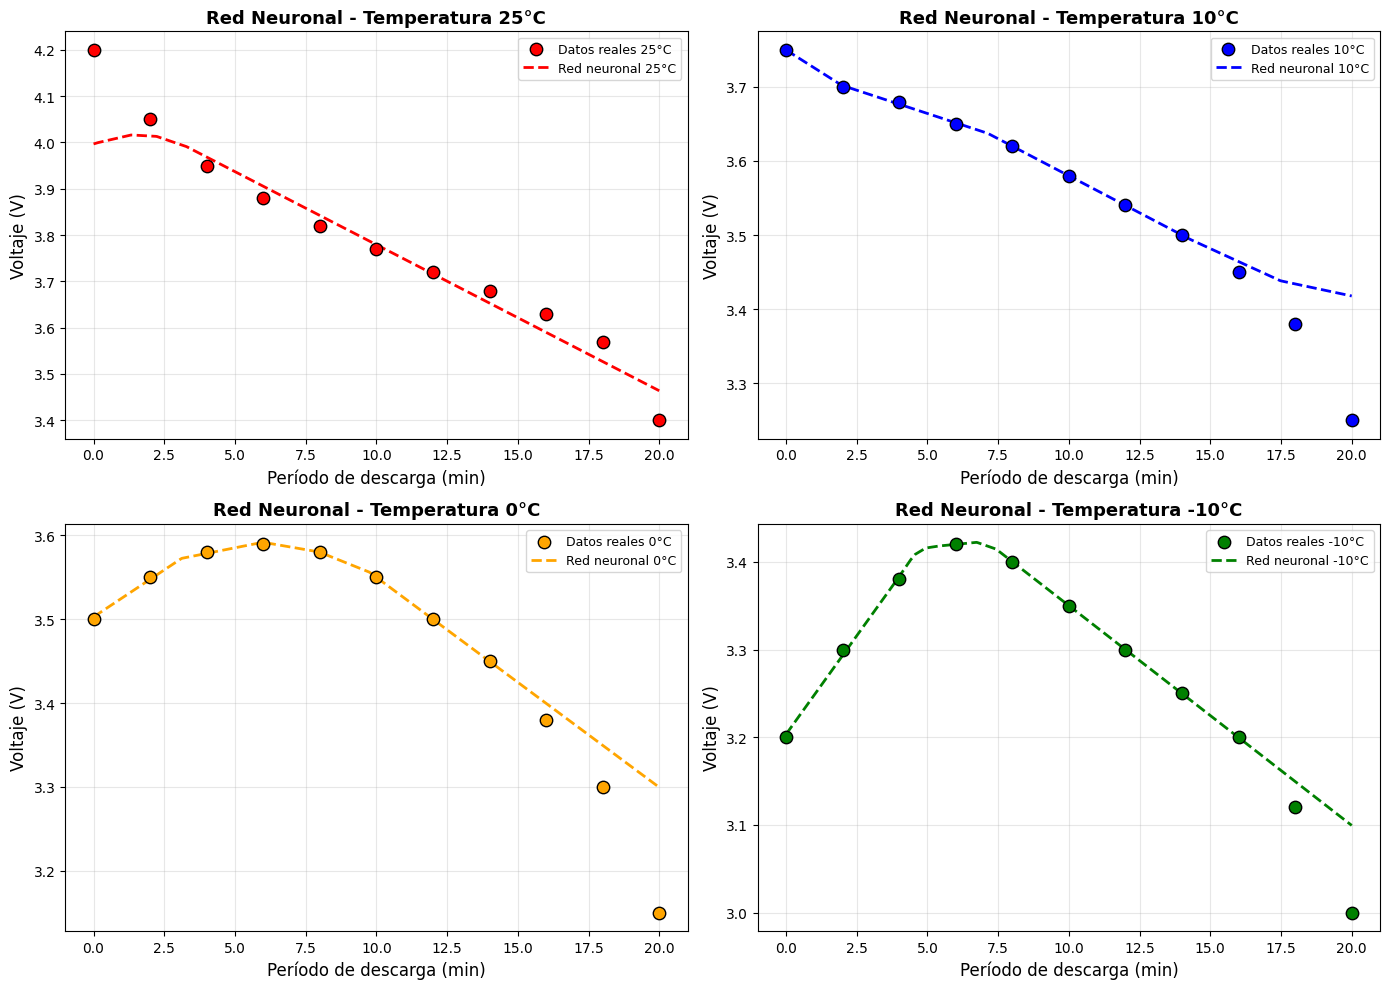

In [6]:
tiempo_denso = np.linspace(0, 20, 500)
tiempo_denso_norm = tiempo_denso / 20.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (ds, modelo, (v_mean, v_std)) in enumerate(zip(datasets, modelos, stats)):
    ax = axes[i // 2][i % 2]
    pred_norm = modelo.predict(tiempo_denso_norm.reshape(-1, 1), verbose=0)
    pred = desnormalizar(pred_norm.flatten(), v_mean, v_std)
    
    ax.scatter(tiempo, ds['voltaje'], color=ds['color'], s=80, edgecolors='black', zorder=5, label=f"Datos reales {ds['label']}")
    ax.plot(tiempo_denso, pred, color=ds['color'], linewidth=2, linestyle='--', label=f"Red neuronal {ds['label']}")
    ax.set_xlabel('Período de descarga (min)', fontsize=12)
    ax.set_ylabel('Voltaje (V)', fontsize=12)
    ax.set_title(f'Red Neuronal - Temperatura {ds["label"]}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problema_1_individual.png', dpi=300, bbox_inches='tight')
plt.show()

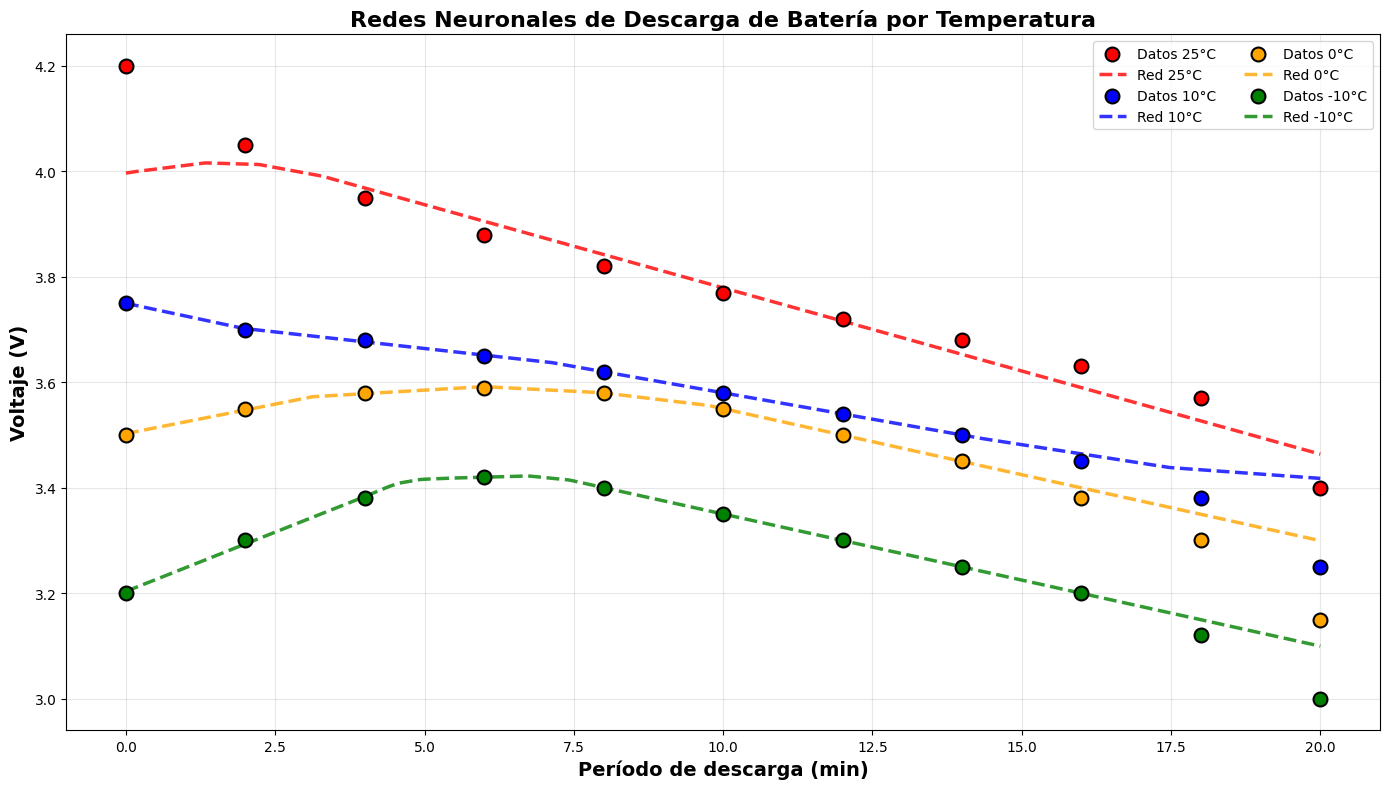

In [7]:
plt.figure(figsize=(14, 8))

for i, (ds, modelo, (v_mean, v_std)) in enumerate(zip(datasets, modelos, stats)):
    pred_norm = modelo.predict(tiempo_denso_norm.reshape(-1, 1), verbose=0)
    pred = desnormalizar(pred_norm.flatten(), v_mean, v_std)
    
    plt.scatter(tiempo, ds['voltaje'], color=ds['color'], s=100, edgecolors='black', linewidth=1.5, zorder=5, label=f"Datos {ds['label']}")
    plt.plot(tiempo_denso, pred, color=ds['color'], linewidth=2.5, linestyle='--', alpha=0.8, label=f"Red {ds['label']}")

plt.xlabel('Período de descarga (min)', fontsize=14, fontweight='bold')
plt.ylabel('Voltaje (V)', fontsize=14, fontweight='bold')
plt.title('Redes Neuronales de Descarga de Batería por Temperatura', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=10, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problema_1_todas_redes.png', dpi=300, bbox_inches='tight')
plt.show()

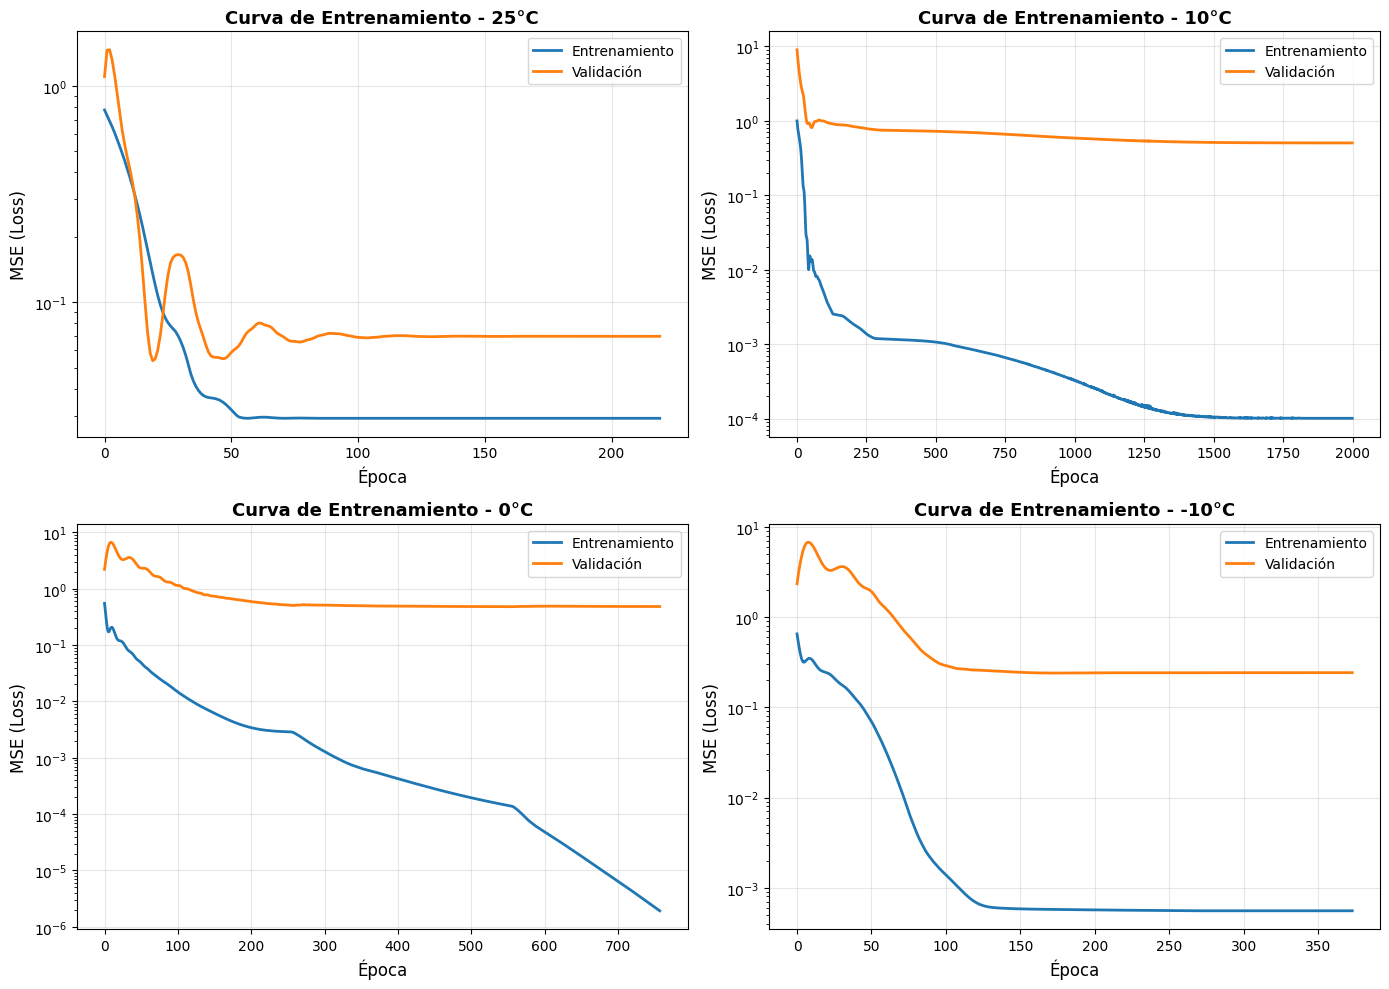

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (ds, history) in enumerate(zip(datasets, historiales)):
    ax = axes[i // 2][i % 2]
    ax.plot(history.history['loss'], label='Entrenamiento', linewidth=2)
    if 'val_loss' in history.history:
        ax.plot(history.history['val_loss'], label='Validación', linewidth=2)
    ax.set_xlabel('Época', fontsize=12)
    ax.set_ylabel('MSE (Loss)', fontsize=12)
    ax.set_title(f'Curva de Entrenamiento - {ds["label"]}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('problema_1_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print(f"{'Temperatura':<15} {'MSE (V²)':<15} {'MAE (V)':<15} {'Error Máx (V)':<15}")
print('=' * 60)

mse_list = []
mae_list = []
labels = []

for ds, modelo, (v_mean, v_std) in zip(datasets, modelos, stats):
    pred_norm = modelo.predict(tiempo_norm.reshape(-1, 1), verbose=0)
    pred = desnormalizar(pred_norm.flatten(), v_mean, v_std)
    
    mse = np.mean((ds['voltaje'] - pred) ** 2)
    mae = np.mean(np.abs(ds['voltaje'] - pred))
    max_err = np.max(np.abs(ds['voltaje'] - pred))
    
    mse_list.append(mse)
    mae_list.append(mae)
    labels.append(ds['label'])
    
    print(f"{ds['label']:<15} {mse:<15.6f} {mae:<15.6f} {max_err:<15.6f}")

Temperatura     MSE (V²)        MAE (V)         Error Máx (V)  
25°C            0.004769        0.044786        0.203240       
10°C            0.002841        0.022102        0.167690       
0°C             0.002293        0.020709        0.149515       


-10°C           0.000986        0.013040        0.099519       


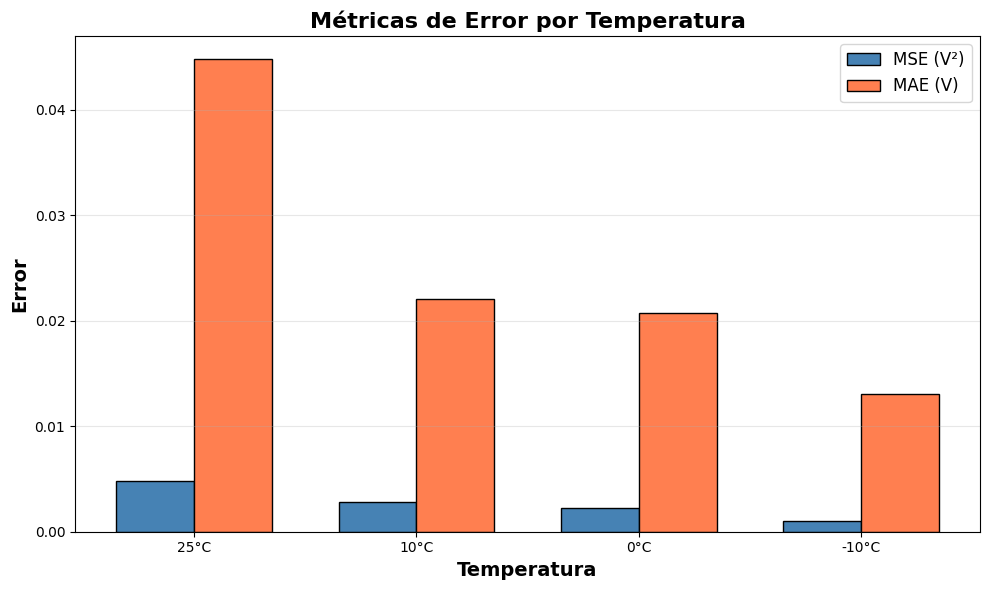

In [10]:
x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_pos - width/2, mse_list, width, label='MSE (V²)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, mae_list, width, label='MAE (V)', color='coral', edgecolor='black')

ax.set_xlabel('Temperatura', fontsize=14, fontweight='bold')
ax.set_ylabel('Error', fontsize=14, fontweight='bold')
ax.set_title('Métricas de Error por Temperatura', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('problema_1_errores.png', dpi=300, bbox_inches='tight')
plt.show()